In [ ]:
import os
import sys

import numpyro
numpyro.set_host_device_count(4)

import numpy as np
import pandas as pd
import arviz as az
import hssm

condition = sys.argv[1]  # T1 or T3

DATA_DIR = "../data"
OUT_DIR = f"../results/hssm_{condition}"
ONNX_PATH = "onnx/ddm_opn.onnx"

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_parquet(f"{DATA_DIR}/after_{condition}.parquet")

tmp_df = df[["RatID", "Trial", "Date", "Correct", "ReactionTime"]].copy()

tmp_df = tmp_df.rename(columns={
    "RatID": "subj_idx",
    "ReactionTime": "rt"
})

tmp_df["response"] = np.where(tmp_df["Correct"].isin([0, 1]), 1, -1)
tmp_df["rt"] = tmp_df["rt"].fillna(-999)
tmp_df["deadline"] = 1.75

model_df = tmp_df[["subj_idx", "rt", "response", "deadline"]].copy()

model_df["rt"] = model_df["rt"].astype("float32")
model_df["deadline"] = model_df["deadline"].astype("float32")
model_df["response"] = model_df["response"].astype("int32")
model_df["subj_idx"] = model_df["subj_idx"].astype("int32")

model_df.to_parquet(f"{OUT_DIR}/{condition}_model_df.parquet")

m = hssm.HSSM(
    data=model_df,
    model="ddm",
    missing_data=True,
    deadline="deadline",
    loglik_kind="approx_differentiable",
    loglik_missing_data=ONNX_PATH
)

draws = 2000
tune = 2000

idata = m.sample(
    sampler="numpyro",
    chains=4,
    cores=4,
    draws=draws,
    tune=tune,
    progressbar=True
)

az.to_netcdf(idata, f"{OUT_DIR}/{condition}_idata.nc")
az.summary(idata).to_csv(f"{OUT_DIR}/{condition}_summary.csv")

print(f"Finished {condition}")

## Read the output

In [1]:
import arviz as az
import pandas as pd

idata_T1 = az.from_netcdf("../results/hssm_T1/T1_idata.nc")
summary_T1 = pd.read_csv("../results/hssm_T1/T1_summary.csv")

idata_T3 = az.from_netcdf("../results/hssm_T3/T3_idata.nc")
summary_T3 = pd.read_csv("../results/hssm_T3/T3_summary.csv")

array([[<Axes: title={'center': 'v'}>, <Axes: title={'center': 'v'}>],
       [<Axes: title={'center': 'a'}>, <Axes: title={'center': 'a'}>],
       [<Axes: title={'center': 'z'}>, <Axes: title={'center': 'z'}>],
       [<Axes: title={'center': 't'}>, <Axes: title={'center': 't'}>]],
      dtype=object)

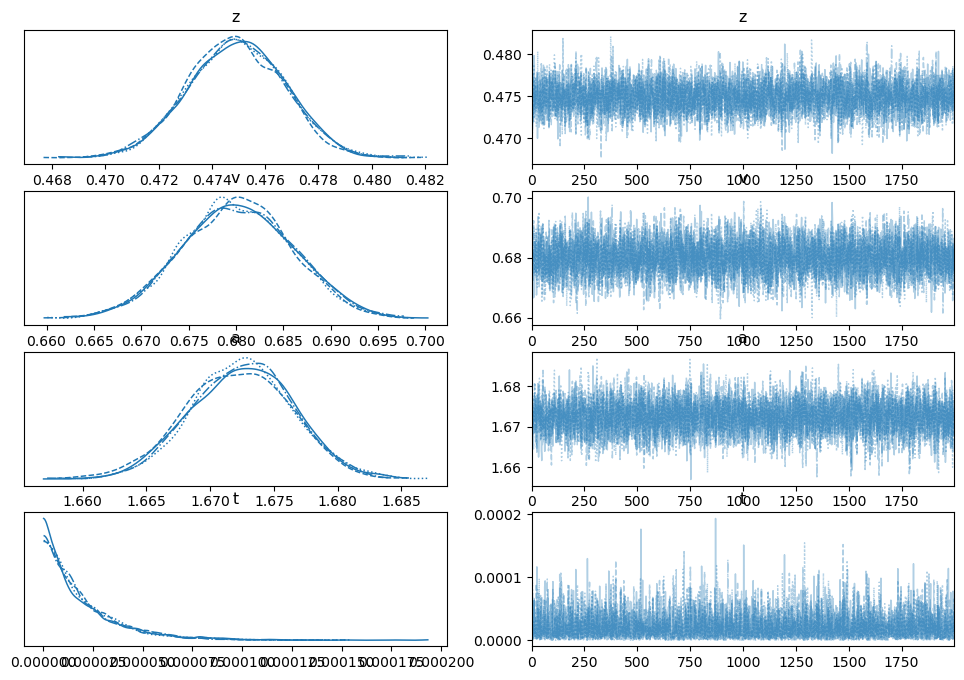

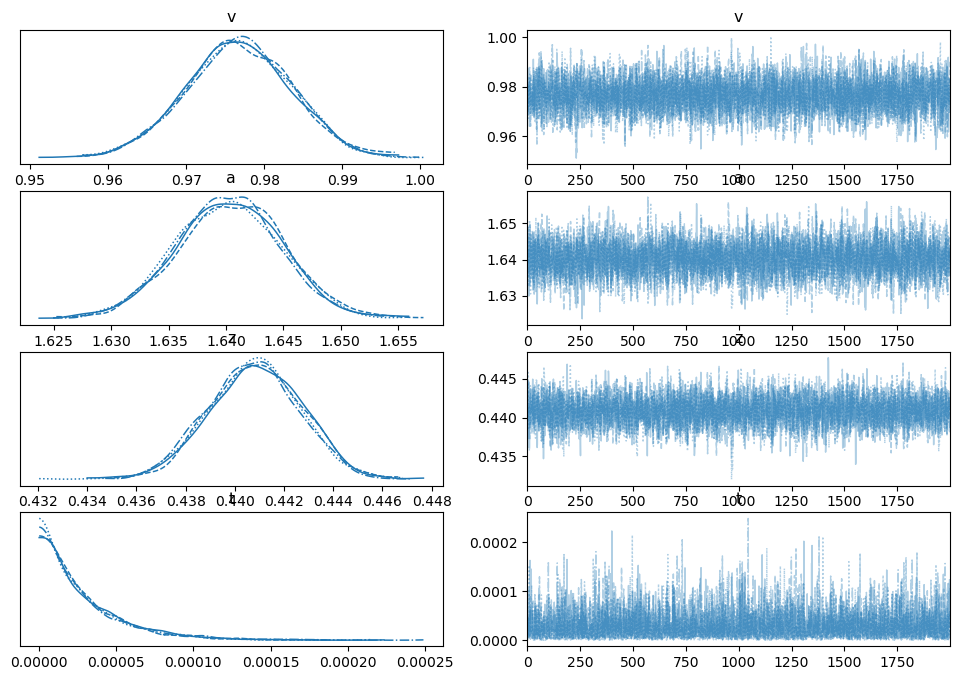

In [2]:
az.plot_trace(idata_T1)
az.plot_trace(idata_T3)

In [5]:
summary_T3.head()

,Unnamed: 0,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,v,0.977,0.007,0.964,0.989,0.0,0.0,4234.0,3841.0,1.0
1,a,1.640,0.005,1.632,1.649,0.0,0.0,4520.0,4162.0,1.0
2,z,0.441,0.002,0.437,0.444,0.0,0.0,4308.0,3440.0,1.0
3,t,0.000,0.000,0.000,0.000,0.0,0.0,4231.0,2955.0,1.0


In [6]:
summary_T1.head()

,Unnamed: 0,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,z,0.475,0.002,0.472,0.478,0.0,0.0,4422.0,4821.0,1.0
1,v,0.680,0.006,0.669,0.691,0.0,0.0,5148.0,4805.0,1.0
2,a,1.672,0.004,1.665,1.680,0.0,0.0,4926.0,4167.0,1.0
3,t,0.000,0.000,0.000,0.000,0.0,0.0,4307.0,2806.0,1.0
